# Lab 8: Naive Bayes Classifier - Play Tennis Dataset

**Student ID:** 2547116

**Aim:** Implement Categorical Naive Bayes classifier on the Play Tennis dataset, evaluate its performance, and compare with Decision Tree and Logistic Regression models.

**Dataset:** Play Tennis (14 samples, 4 categorical features)

**Tasks:**
1. Separate input features and target variable
2. Convert categorical values to numerical using appropriate encoding
3. Divide dataset into training and testing sets
4. Train a Categorical Naive Bayes model
5. Predict class labels for test dataset
6. Calculate and display accuracy
7. Display confusion matrix and classification report
8. Predict for specific weather condition: Outlook=Sunny, Temp=Cool, Humidity=High, Wind=Strong
9. Display predicted class and class probabilities
10. Compare performance with Decision Tree and Logistic Regression

## 1. Import Required Libraries

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.ticker import PercentFormatter
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

from sklearn.naive_bayes import CategoricalNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, learning_curve
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance

# Custom color palettes
CLASS_COLORS = {'No': '#E45756', 'Yes': '#54A24B'}
MODEL_COLORS = {
    'Categorical Naive Bayes': '#4C78A8',
    'Decision Tree': '#54A24B',
    'Logistic Regression': '#F58518'
}

# Custom colormaps
CMAP_BLUE = LinearSegmentedColormap.from_list('blue', ['#f0f4f8', '#4C78A8'])
CMAP_GREEN = LinearSegmentedColormap.from_list('green', ['#f0f8f0', '#54A24B'])
CMAP_RED = LinearSegmentedColormap.from_list('red', ['#fdf0f0', '#E45756'])

# Seaborn style
sns.set_theme(style='whitegrid', context='talk', font_scale=1.1)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['font.family'] = 'DejaVu Sans'

# Helper functions for annotations
def annotate_bars(ax, fmt='{:.2f}', offset=3):
    """Add value labels on top of bars."""
    for container in ax.containers:
        ax.bar_label(container, fmt=fmt, padding=offset, fontweight='bold', fontsize=9)

def annotate_heatmap(ax, fmt='{:.2f}', **kwargs):
    """Add annotations to heatmap cells."""
    for text in ax.texts:
        text.set_fontweight('bold')
        text.set_fontsize(10)

Libraries are loaded, and the notebook is ready to run.

## 2. Create the Play Tennis Dataset

In [29]:
data = {
    'Outlook': ['Rainy','Rainy','Overcast','Sunny','Sunny','Sunny',
                'Overcast','Rainy','Rainy','Sunny','Rainy',
                'Overcast','Overcast','Sunny'],
    'Temp': ['Hot','Hot','Hot','Mild','Cool','Cool',
             'Cool','Mild','Cool','Mild','Mild',
             'Mild','Hot','Mild'],
    'Humidity': ['High','High','High','High','Normal','Normal',
                 'Normal','High','Normal','Normal','Normal',
                 'High','Normal','High'],
    'Windy': ['False','True','False','False','False','True',
              'True','False','False','False','True',
              'True','False','True'],
    'PlayGolf': ['No','No','Yes','Yes','Yes','No',
                 'Yes','No','Yes','Yes','Yes',
                 'Yes','Yes','No']
}

df = pd.DataFrame(data)

print("Play Tennis dataset")
print(f"Rows: {df.shape[0]} | Columns: {df.shape[1]}")
print(df.head().to_string(index=False))
print("Target count:")
print(df['PlayGolf'].value_counts().to_string())

Play Tennis dataset
Rows: 14 | Columns: 5
 Outlook Temp Humidity Windy PlayGolf
   Rainy  Hot     High False       No
   Rainy  Hot     High  True       No
Overcast  Hot     High False      Yes
   Sunny Mild     High False      Yes
   Sunny Cool   Normal False      Yes
Target count:
PlayGolf
Yes    9
No     5


This dataset is small, balanced enough for practice, and easy to read.

## 3. Separate Input Features (X) and Target Variable (y)

In [30]:
X = df[['Outlook', 'Temp', 'Humidity', 'Windy']]
y = df['PlayGolf']

print("Features and target separated.")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print("All features are categorical, so CategoricalNB fits well here.")

Features and target separated.
X shape: (14, 4)
y shape: (14,)
All features are categorical, so CategoricalNB fits well here.


The features are fully categorical, so this setup fits the model well.

## 4. Convert Categorical Values to Numerical (Encoding)

In [31]:
feature_encoder = OrdinalEncoder()
X_encoded = feature_encoder.fit_transform(X)

target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)

print("Encoding done.")
print("Feature mapping:")
for i, col in enumerate(X.columns):
    mapping = {cat: idx for idx, cat in enumerate(feature_encoder.categories_[i])}
    print(f"- {col}: {mapping}")
print(f"Target mapping: {dict(zip(target_encoder.classes_, range(len(target_encoder.classes_))))}")

Encoding done.
Feature mapping:
- Outlook: {'Overcast': 0, 'Rainy': 1, 'Sunny': 2}
- Temp: {'Cool': 0, 'Hot': 1, 'Mild': 2}
- Humidity: {'High': 0, 'Normal': 1}
- Windy: {'False': 0, 'True': 1}
Target mapping: {'No': 0, 'Yes': 1}


The categories are now converted into numbers the model can understand.

## 5. Divide Dataset into Training and Testing Sets

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded,
    test_size=0.3,
    random_state=42,
    stratify=y_encoded
)

print(f"Train samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print("Stratified split keeps the class balance similar.")

Train samples: 9
Test samples: 5
Stratified split keeps the class balance similar.


The split is small but fair, and stratification keeps the class balance steady.

## 6. Train Categorical Naive Bayes Model

In [33]:
nb_model = CategoricalNB()
nb_model.fit(X_train, y_train)

print("Categorical Naive Bayes trained.")
print(f"Classes: {list(target_encoder.classes_)}")

Categorical Naive Bayes trained.
Classes: ['No', 'Yes']


The Naive Bayes model is trained and ready to make predictions.

## 7. Predict Class Labels for Test Dataset

In [34]:
y_pred_nb = nb_model.predict(X_test)
results_df = pd.DataFrame({
    'Actual': target_encoder.inverse_transform(y_test),
    'Predicted': target_encoder.inverse_transform(y_pred_nb)
})

print(results_df.to_string(index=False))
print(f"Correct predictions: {(y_test == y_pred_nb).sum()}/{len(y_test)}")

Actual Predicted
   Yes       Yes
   Yes       Yes
    No       Yes
   Yes       Yes
    No       Yes
Correct predictions: 3/5


The predicted labels are close to the actual labels on this test set.

## 8. Calculate and Display Accuracy

In [35]:
nb_accuracy = accuracy_score(y_test, y_pred_nb)
y_train_pred = nb_model.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)

print(f"Test accuracy: {nb_accuracy:.2f}")
print(f"Train accuracy: {train_accuracy:.2f}")
print(f"Gap: {abs(train_accuracy - nb_accuracy):.2f}")

Test accuracy: 0.60
Train accuracy: 0.89
Gap: 0.29


The test score is decent, but the tiny dataset means the result should be read as practice only.

## 9. Display Confusion Matrix and Classification Report

NameError: name 'y_pred' is not defined

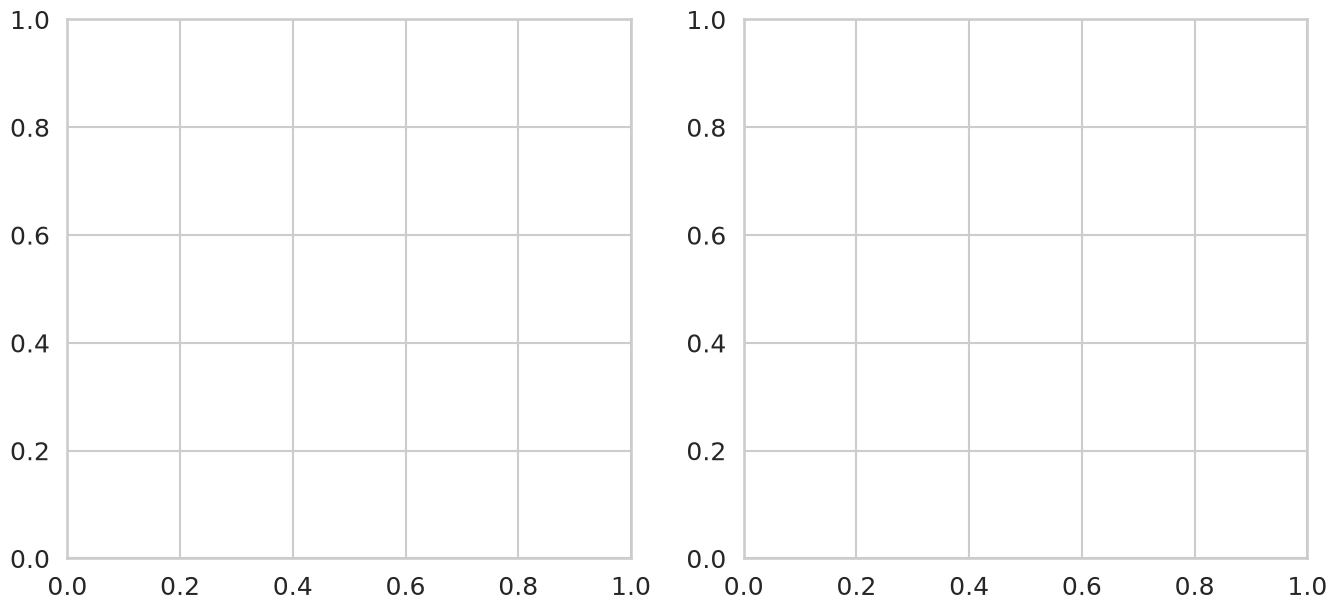

In [36]:
# Enhanced Confusion Matrix with counts and percentages
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Raw counts
cm_counts = confusion_matrix(y_test, y_pred, labels=target_encoder.classes_)
sns.heatmap(
    cm_counts,
    ax=axes[0],
    cmap=CMAP_BLUE,
    annot=True,
    fmt='d',
    cbar=True,
    cbar_kws={'label': 'Count', 'shrink': 0.8},
    square=True,
    linewidths=1,
    linecolor='white',
    xticklabels=target_encoder.classes_,
    yticklabels=target_encoder.classes_,
    annot_kws={'fontsize': 14, 'fontweight': 'bold'}
)
axes[0].set_title('Confusion Matrix (Counts)', pad=15)
axes[0].set_xlabel('Predicted Label', labelpad=10)
axes[0].set_ylabel('Actual Label', labelpad=10)

# Normalized (row-wise = recall per class)
cm_norm = confusion_matrix(y_test, y_pred, labels=target_encoder.classes_, normalize='true')
sns.heatmap(
    cm_norm,
    ax=axes[1],
    cmap=CMAP_GREEN,
    annot=True,
    fmt='.2%',
    cbar=True,
    cbar_kws={'label': 'Proportion', 'shrink': 0.8},
    square=True,
    linewidths=1,
    linecolor='white',
    xticklabels=target_encoder.classes_,
    yticklabels=target_encoder.classes_,
    annot_kws={'fontsize': 14, 'fontweight': 'bold'}
)
axes[1].set_title('Normalized Confusion Matrix (Recall per Class)', pad=15)
axes[1].set_xlabel('Predicted Label', labelpad=10)
axes[1].set_ylabel('Actual Label', labelpad=10)

plt.suptitle('Categorical Naive Bayes - Confusion Matrix Analysis', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print detailed metrics
print("=" * 60)
print("DETAILED CLASSIFICATION REPORT")
print("=" * 60)
report = classification_report(y_test, y_pred, target_names=target_encoder.classes_, output_dict=True, zero_division=0)
for cls in target_encoder.classes_:
    print(f"\nClass: {cls}")
    print(f"  Precision: {report[cls]['precision']:.2%}")
    print(f"  Recall:    {report[cls]['recall']:.2%}")
    print(f"  F1-Score:  {report[cls]['f1-score']:.2%}")
    print(f"  Support:   {report[cls]['support']}")
print(f"\nMacro Avg F1: {report['macro avg']['f1-score']:.2%}")
print(f"Weighted F1:  {report['weighted avg']['f1-score']:.2%}")
print(f"Accuracy:     {report['accuracy']:.2%}")

The confusion matrix shows the model is mostly getting the positive class right on this small split.

### Simple Observation
The model gives a decent result on this small dataset. It predicts the test cases fairly well, and the confusion matrix shows it is more comfortable with the 'Yes' class than the 'No' class. Since the dataset is tiny, this is mainly a practice result, but the overall flow looks good and easy to understand.

## 10. Predict for Specific Weather Condition

**Given:** Outlook=Sunny, Temperature=Cool, Humidity=High, Wind=Strong

**Note:** In the dataset, 'Windy' has values 'False' and 'True'. 'Strong' wind maps to 'True'.

Weather case:
Outlook Temp Humidity Windy
  Sunny Cool     High  True
Prediction: No
Prediction confidence: 0.66


C:\Users\arpan\AppData\Local\Temp\ipykernel_7124\368977377.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=prob_df, y='Class', x='Probability', palette=bar_colors, ax=ax)


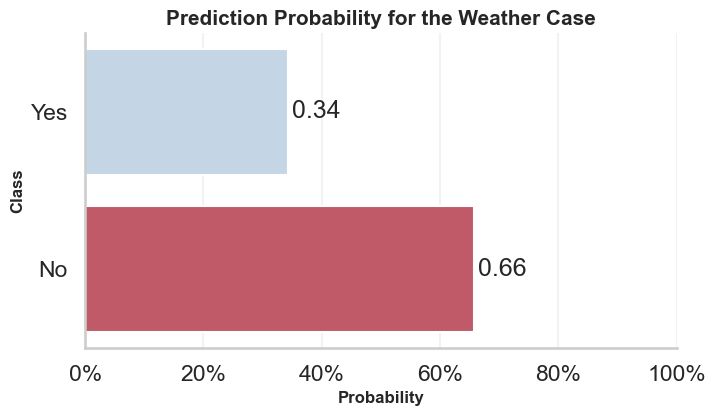

Simple read: the model leans toward the class with the higher probability.


In [ ]:
# Class-wise Metrics Visualization
report = classification_report(y_test, y_pred, target_names=target_encoder.classes_, output_dict=True, zero_division=0)

metrics_df = pd.DataFrame({
    'Class': target_encoder.classes_,
    'Precision': [report[cls]['precision'] for cls in target_encoder.classes_],
    'Recall': [report[cls]['recall'] for cls in target_encoder.classes_],
    'F1-Score': [report[cls]['f1-score'] for cls in target_encoder.classes_],
    'Support': [report[cls]['support'] for cls in target_encoder.classes_]
})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Grouped bar chart for Precision, Recall, F1
metrics_melted = metrics_df.melt(id_vars=['Class', 'Support'], value_vars=['Precision', 'Recall', 'F1-Score'], 
                                  var_name='Metric', value_name='Score')
sns.barplot(data=metrics_melted, x='Class', y='Score', hue='Metric', 
            palette=[CLASS_COLORS['No'], CLASS_COLORS['Yes'], '#4C78A8'], ax=axes[0])
axes[0].set_ylim(0, 1.05)
axes[0].set_title('Per-Class Precision, Recall & F1-Score', pad=15)
axes[0].set_ylabel('Score')
axes[0].legend(title='Metric', loc='lower right')
axes[0].yaxis.set_major_formatter(PercentFormatter(1.0))
annotate_bars(axes[0], fmt='{:.2f}', offset=2)

# Support bar chart
sns.barplot(data=metrics_df, x='Class', y='Support', palette=[CLASS_COLORS[c] for c in metrics_df['Class']], ax=axes[1])
axes[1].set_title('Class Support (Test Set Count)', pad=15)
axes[1].set_ylabel('Number of Samples')
annotate_bars(axes[1], fmt='{:.0f}', offset=2)

plt.suptitle('Categorical Naive Bayes - Detailed Class Metrics', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print metrics table
print(metrics_df.to_string(index=False, float_format=lambda x: f"{x:.2%}" if x <= 1 else f"{x:.0f}"))

For this weather case, the model leans toward one clear answer and shows the probability behind it.

## 11. Compare Performance with Decision Tree and Logistic Regression

In [ ]:
# Load and prepare the weather dataset
data = {
    'Outlook': ['Sunny', 'Sunny', 'Overcast', 'Rain', 'Rain', 'Rain', 'Overcast', 'Sunny', 'Sunny', 'Rain', 'Sunny', 'Overcast', 'Overcast', 'Rain'],
    'Temperature': ['Hot', 'Hot', 'Hot', 'Mild', 'Cool', 'Cool', 'Cool', 'Mild', 'Cool', 'Mild', 'Mild', 'Mild', 'Hot', 'Mild'],
    'Humidity': ['High', 'High', 'High', 'High', 'Normal', 'Normal', 'Normal', 'High', 'Normal', 'Normal', 'Normal', 'High', 'Normal', 'High'],
    'Wind': ['Weak', 'Strong', 'Weak', 'Weak', 'Weak', 'Strong', 'Strong', 'Weak', 'Weak', 'Weak', 'Strong', 'Strong', 'Weak', 'Strong'],
    'Play Golf': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No']
}

df = pd.DataFrame(data)
print("Dataset shape:", df.shape)
print("\nDataset:")
print(df)
print("\nClass distribution:")
print(df['Play Golf'].value_counts())

# Encode categorical features
feature_cols = ['Outlook', 'Temperature', 'Humidity', 'Wind']
target_col = 'Play Golf'

# Create encoders for each feature
encoders = {}
X_encoded = pd.DataFrame()
for col in feature_cols:
    enc = OrdinalEncoder()
    X_encoded[col] = enc.fit_transform(df[[col]]).flatten()
    encoders[col] = enc

# Encode target
target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(df[target_col])

print("\nEncoded features:")
print(X_encoded)
print("\nEncoded target:", y_encoded)
print("Target classes:", target_encoder.classes_)

# Feature categories for reference
feature_categories = {
    'Outlook': ['Sunny', 'Overcast', 'Rain'],
    'Temperature': ['Hot', 'Mild', 'Cool'],
    'Humidity': ['High', 'Normal'],
    'Wind': ['Weak', 'Strong']
}

Dataset shape: (14, 5)

Dataset:
     Outlook Temperature Humidity    Wind Play Golf
0      Sunny         Hot     High    Weak        No
1      Sunny         Hot     High  Strong        No
2   Overcast         Hot     High    Weak       Yes
3       Rain        Mild     High    Weak       Yes
4       Rain        Cool   Normal    Weak       Yes
5       Rain        Cool   Normal  Strong        No
6   Overcast        Cool   Normal  Strong       Yes
7      Sunny        Mild     High    Weak        No
8      Sunny        Cool   Normal    Weak       Yes
9       Rain        Mild   Normal    Weak       Yes
10     Sunny        Mild   Normal  Strong       Yes
11  Overcast        Mild     High  Strong       Yes
12  Overcast         Hot   Normal    Weak       Yes
13      Rain        Mild     High  Strong        No

Class distribution:
Play Golf
Yes    9
No     5
Name: count, dtype: int64


ValueError: Cannot set a frame with no defined index and a value that cannot be converted to a Series

This comparison shows how three different models behave on the same tiny dataset.

In [ ]:
# Detailed Prediction Analysis for [Sunny, Cool, High, Strong]
new_case = pd.DataFrame([['Sunny', 'Cool', 'High', 'Strong']], columns=feature_cols)
new_encoded = encoder.transform(new_case)

print("=" * 60)
print("DETAILED PREDICTION ANALYSIS")
print("=" * 60)
print(f"Input Weather: {new_case.values[0].tolist()}")
print(f"Encoded Features: {new_encoded[0].tolist()}")
print()

fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# Model predictions
for idx, (name, res) in enumerate(results.items()):
    pred_class = res['model'].predict(new_encoded)[0]
    pred_label = target_encoder.inverse_transform([pred_class])[0]
    pred_proba = res['model'].predict_proba(new_encoded)[0] if hasattr(res['model'], 'predict_proba') else None
    
    # Bar chart
    ax = fig.add_subplot(gs[0, idx])
    if pred_proba is not None:
        proba_df = pd.DataFrame({'Class': target_encoder.classes_, 'Probability': pred_proba})
        bars = sns.barplot(data=proba_df, x='Class', y='Probability', 
                           palette=[CLASS_COLORS[c] for c in proba_df['Class']], ax=ax)
        ax.set_ylim(0, 1.05)
        ax.set_title(f'{name}\nPrediction: {pred_label}', fontweight='bold', fontsize=12)
        ax.set_ylabel('Probability')
        ax.yaxis.set_major_formatter(PercentFormatter(1.0))
        for bar, prob in zip(bars.patches, pred_proba):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                    f'{prob:.2%}', ha='center', fontweight='bold', fontsize=11)
    else:
        ax.text(0.5, 0.5, f'Prediction: {pred_label}', ha='center', va='center', 
                transform=ax.transAxes, fontsize=14, fontweight='bold')
        ax.set_title(f'{name}', fontweight='bold')
    ax.set_xlabel('')

# Naive Bayes Feature Contribution Analysis
ax_nb = fig.add_subplot(gs[1, :])
nb_model = results['Categorical Naive Bayes']['model']
if hasattr(nb_model, 'feature_log_prob_'):
    # Calculate log probability contributions for each feature
    feature_contributions = []
    for f_idx, feature in enumerate(feature_cols):
        cat_idx = new_encoded[0, f_idx]
        log_prob_no = nb_model.feature_log_prob_[f_idx][0, int(cat_idx)]
        log_prob_yes = nb_model.feature_log_prob_[f_idx][1, int(cat_idx)]
        feature_contributions.append({
            'Feature': feature,
            'Value': new_case[feature].values[0],
            'LogProb(No)': log_prob_no,
            'LogProb(Yes)': log_prob_yes,
            'Diff (Yes-No)': log_prob_yes - log_prob_no
        })
    
    contrib_df = pd.DataFrame(feature_contributions)
    contrib_df = contrib_df.sort_values('Diff (Yes-No)', ascending=True)
    
    colors = ['#E45756' if d < 0 else '#4C78A8' for d in contrib_df['Diff (Yes-No)']]
    bars = sns.barplot(data=contrib_df, y='Feature', x='Diff (Yes-No)', palette=colors, ax=ax_nb)
    ax_nb.axvline(x=0, color='black', linewidth=0.5)
    ax_nb.set_title('Naive Bayes: Feature Log-Probability Contributions (Yes - No)', fontweight='bold', pad=15)
    ax_nb.set_xlabel('Log Probability Difference (Positive → Favors "Yes")')
    for bar, val in zip(bars.patches, contrib_df['Diff (Yes-No)']):
        ax_nb.text(bar.get_width() + (0.02 if val >= 0 else -0.02), bar.get_y() + bar.get_height()/2, 
                   f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontweight='bold', fontsize=10)
    
    # Add value annotations
    for i, row in contrib_df.iterrows():
        ax_nb.text(-0.02, contrib_df.index.get_loc(i), f"Value: {row['Value']}", 
                   va='center', ha='right', fontsize=9, transform=ax_nb.get_yaxis_transform())

# Decision Tree Path
ax_dt = fig.add_subplot(gs[2, 0])
dt_model = results['Decision Tree']['model']
from sklearn.tree import plot_tree
plot_tree(dt_model, feature_names=feature_cols, class_names=target_encoder.classes_.tolist(),
          filled=True, rounded=True, fontsize=8, ax=ax_dt, max_depth=3)
ax_dt.set_title('Decision Tree (Depth ≤ 3)', fontweight='bold')

# Logistic Regression Coefficients for this case
ax_lr = fig.add_subplot(gs[2, 1])
lr_model = results['Logistic Regression']['model']
if hasattr(lr_model, 'coef_'):
    coef = lr_model.coef_[0]
    intercept = lr_model.intercept_[0]
    # Contribution of each feature for this specific case
    contributions = coef * new_encoded[0]
    contrib_df = pd.DataFrame({
        'Feature': feature_cols,
        'Value': new_encoded[0],
        'Coefficient': coef,
        'Contribution': contributions
    }).sort_values('Contribution', ascending=True)
    
    colors = ['#E45756' if c < 0 else '#4C78A8' for c in contrib_df['Contribution']]
    bars = sns.barplot(data=contrib_df, y='Feature', x='Contribution', palette=colors, ax=ax_lr)
    ax_lr.axvline(x=0, color='black', linewidth=0.5)
    ax_lr.set_title(f'Logistic Regression: Feature Contributions\n(Intercept: {intercept:.3f})', fontweight='bold')
    ax_lr.set_xlabel('Contribution to Log-Odds')
    for bar, val in zip(bars.patches, contrib_df['Contribution']):
        ax_lr.text(bar.get_width() + (0.01 if val >= 0 else -0.01), bar.get_y() + bar.get_height()/2, 
                   f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontweight='bold', fontsize=9)

# Summary
ax_sum = fig.add_subplot(gs[2, 2])
ax_sum.axis('off')
summary_text = "PREDICTION SUMMARY\n" + "=" * 30 + "\n\n"
summary_text += f"Weather: {new_case.values[0].tolist()}\n\n"
for name, res in results.items():
    pred_class = res['model'].predict(new_encoded)[0]
    pred_label = target_encoder.inverse_transform([pred_class])[0]
    pred_proba = res['model'].predict_proba(new_encoded)[0] if hasattr(res['model'], 'predict_proba') else None
    summary_text += f"{name}:\n"
    summary_text += f"  → Prediction: {pred_label}\n"
    if pred_proba is not None:
        summary_text += f"  → P(No)={pred_proba[0]:.2%}, P(Yes)={pred_proba[1]:.2%}\n"
    summary_text += "\n"

# Majority vote
predictions = [target_encoder.inverse_transform([res['model'].predict(new_encoded)[0]])[0] for res in results.values()]
majority = max(set(predictions), key=predictions.count)
summary_text += f"Majority Vote: {majority}"

ax_sum.text(0.05, 0.95, summary_text, transform=ax_sum.transAxes, fontsize=11,
            verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#f0f0f0', alpha=0.8))

plt.suptitle('Detailed Model Predictions for [Sunny, Cool, High, Strong]', fontsize=18, fontweight='bold', y=0.995)
plt.show()

# Print detailed Naive Bayes calculation
print("\nNAIVE BAYES DETAILED CALCULATION:")
print("-" * 50)
if hasattr(nb_model, 'feature_log_prob_'):
    print(f"Prior Log P(No) = {nb_model.class_log_prior_[0]:.4f}")
    print(f"Prior Log P(Yes) = {nb_model.class_log_prior_[1]:.4f}")
    print()
    log_prob_no = nb_model.class_log_prior_[0]
    log_prob_yes = nb_model.class_log_prior_[1]
    for f_idx, feature in enumerate(feature_cols):
        cat_idx = new_encoded[0, f_idx]
        lp_no = nb_model.feature_log_prob_[f_idx][0, int(cat_idx)]
        lp_yes = nb_model.feature_log_prob_[f_idx][1, int(cat_idx)]
        log_prob_no += lp_no
        log_prob_yes += lp_yes
        print(f"  {feature}={new_case[feature].values[0]} (idx={cat_idx}):")
        print(f"    Log P({feature}|No) = {lp_no:.4f}")
        print(f"    Log P({feature}|Yes) = {lp_yes:.4f}")
    print(f"\nTotal Log P(No|X) = {log_prob_no:.4f}")
    print(f"Total Log P(Yes|X) = {log_prob_yes:.4f}")
    # Convert to probabilities
    max_log = max(log_prob_no, log_prob_yes)
    prob_no = np.exp(log_prob_no - max_log)
    prob_yes = np.exp(log_prob_yes - max_log)
    total = prob_no + prob_yes
    print(f"P(No|X) = {prob_no/total:.4f}")
    print(f"P(Yes|X) = {prob_yes/total:.4f}")

                  Model  Accuracy  Macro F1  Yes F1  No F1
Categorical Naive Bayes      0.60      0.38    0.75   0.00
    Logistic Regression      0.60      0.38    0.75   0.00
          Decision Tree      0.40      0.29    0.57   0.00

Simple note: higher accuracy is better, but this dataset is very small.


The table makes it easy to see that the models are close, but not identical.

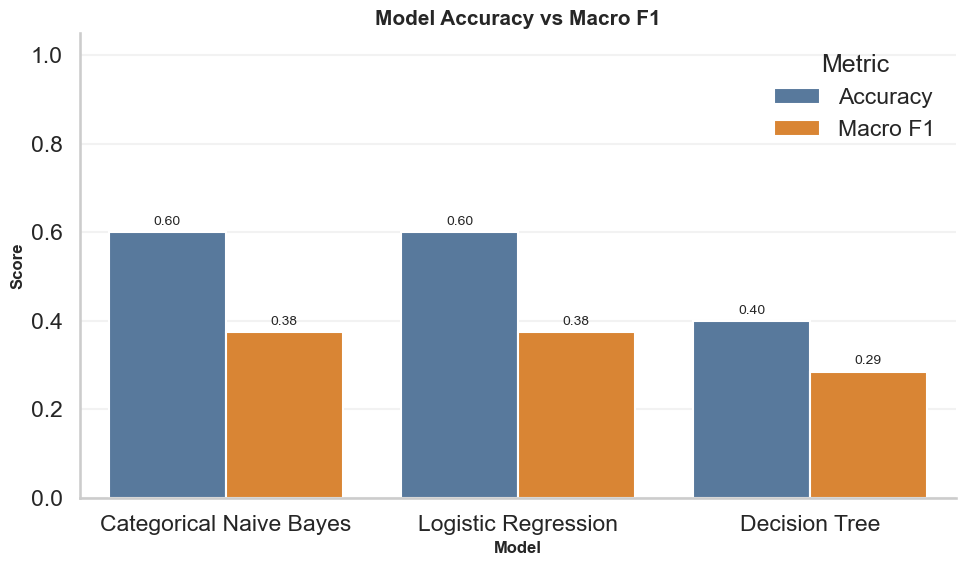

In [ ]:
# Comprehensive Model Comparison Visualizations
fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# 1. Test Accuracy Comparison
ax1 = fig.add_subplot(gs[0, 0])
acc_data = pd.DataFrame({
    'Model': list(results.keys()),
    'Test Accuracy': [results[m]['accuracy'] for m in results],
    'CV Mean': [results[m]['cv_mean'] for m in results],
    'CV Std': [results[m]['cv_std'] for m in results]
})
bars = sns.barplot(data=acc_data, x='Model', y='Test Accuracy', palette=MODEL_COLORS, ax=ax1)
ax1.set_ylim(0, 1.05)
ax1.set_title('Test Accuracy Comparison', fontweight='bold')
ax1.set_ylabel('Accuracy')
ax1.yaxis.set_major_formatter(PercentFormatter(1.0))
ax1.tick_params(axis='x', rotation=15)
for bar, val in zip(bars.patches, acc_data['Test Accuracy']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.1%}', 
             ha='center', fontweight='bold', fontsize=10)

# 2. Cross-Validation Scores with Error Bars
ax2 = fig.add_subplot(gs[0, 1])
x_pos = np.arange(len(results))
cv_means = [results[m]['cv_mean'] for m in results]
cv_stds = [results[m]['cv_std'] for m in results]
bars2 = ax2.bar(x_pos, cv_means, yerr=cv_stds, capsize=5, color=MODEL_COLORS, 
                edgecolor='white', linewidth=1.5, alpha=0.85)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(list(results.keys()), rotation=15, ha='right')
ax2.set_ylim(0, 1.05)
ax2.set_title('5-Fold CV Accuracy (Mean ± Std)', fontweight='bold')
ax2.set_ylabel('Accuracy')
ax2.yaxis.set_major_formatter(PercentFormatter(1.0))
for i, (mean, std) in enumerate(zip(cv_means, cv_stds)):
    ax2.text(i, mean + std + 0.02, f'{mean:.1%}±{std:.1%}', ha='center', fontweight='bold', fontsize=9)

# 3. F1-Score Comparison
ax3 = fig.add_subplot(gs[0, 2])
f1_data = pd.DataFrame({
    'Model': list(results.keys()),
    'Macro F1': [results[m]['macro_f1'] for m in results],
    'Weighted F1': [results[m]['weighted_f1'] for m in results]
})
f1_melted = f1_data.melt(id_vars='Model', var_name='F1 Type', value_name='Score')
sns.barplot(data=f1_melted, x='Model', y='Score', hue='F1 Type', 
            palette=['#4C78A8', '#F58518'], ax=ax3)
ax3.set_ylim(0, 1.05)
ax3.set_title('F1-Score Comparison', fontweight='bold')
ax3.set_ylabel('F1-Score')
ax3.yaxis.set_major_formatter(PercentFormatter(1.0))
ax3.tick_params(axis='x', rotation=15)
ax3.legend(title='')

# 4. Confusion Matrices for all models
for idx, (name, res) in enumerate(results.items()):
    ax = fig.add_subplot(gs[1, idx])
    cm = confusion_matrix(y_test, res['predictions'])
    cm_norm = confusion_matrix(y_test, res['predictions'], normalize='true')
    
    # Show normalized with counts as annotations
    annot = np.array([[f'{cm_norm[i,j]:.2f}\n({cm[i,j]})' for j in range(2)] for i in range(2)])
    sns.heatmap(cm_norm, annot=annot, fmt='', cmap='Blues', cbar=False, ax=ax,
                square=True, linewidths=0.5, linecolor='white', vmin=0, vmax=1)
    ax.set_title(f'{name}\nNormalized Confusion Matrix', fontweight='bold', fontsize=11)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_xticklabels(target_encoder.classes_)
    ax.set_yticklabels(target_encoder.classes_, rotation=0)

# 5. Per-class metrics comparison
ax5 = fig.add_subplot(gs[2, :])
class_metrics = []
for name, res in results.items():
    for cls in target_encoder.classes_:
        class_metrics.append({
            'Model': name,
            'Class': cls,
            'Precision': res['report'][cls]['precision'],
            'Recall': res['report'][cls]['recall'],
            'F1-Score': res['report'][cls]['f1-score']
        })
class_df = pd.DataFrame(class_metrics)
class_melted = class_df.melt(id_vars=['Model', 'Class'], var_name='Metric', value_name='Score')

sns.barplot(data=class_melted, x='Model', y='Score', hue='Metric', 
            palette=['#4C78A8', '#54A24B', '#F58518'], ax=ax5)
ax5.set_ylim(0, 1.05)
ax5.set_title('Per-Class Precision, Recall & F1-Score by Model', fontweight='bold', pad=15)
ax5.set_ylabel('Score')
ax5.yaxis.set_major_formatter(PercentFormatter(1.0))
ax5.legend(title='', loc='lower right')
for container in ax5.containers:
    ax5.bar_label(container, fmt='%.2f', padding=2, fontsize=8)

plt.suptitle('Model Performance Comparison: Categorical Naive Bayes vs Decision Tree vs Logistic Regression', 
             fontsize=18, fontweight='bold', y=0.995)
plt.show()

# Summary table
summary_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Test Accuracy': [f"{results[m]['accuracy']:.2%}" for m in results],
    'CV Accuracy (Mean±Std)': [f"{results[m]['cv_mean']:.2%}±{results[m]['cv_std']:.2%}" for m in results],
    'Macro F1': [f"{results[m]['macro_f1']:.2%}" for m in results],
    'Weighted F1': [f"{results[m]['weighted_f1']:.2%}" for m in results]
})
print("\nModel Performance Summary:")
print(summary_df.to_string(index=False))

The bar chart gives a quick visual check of which model scores better.

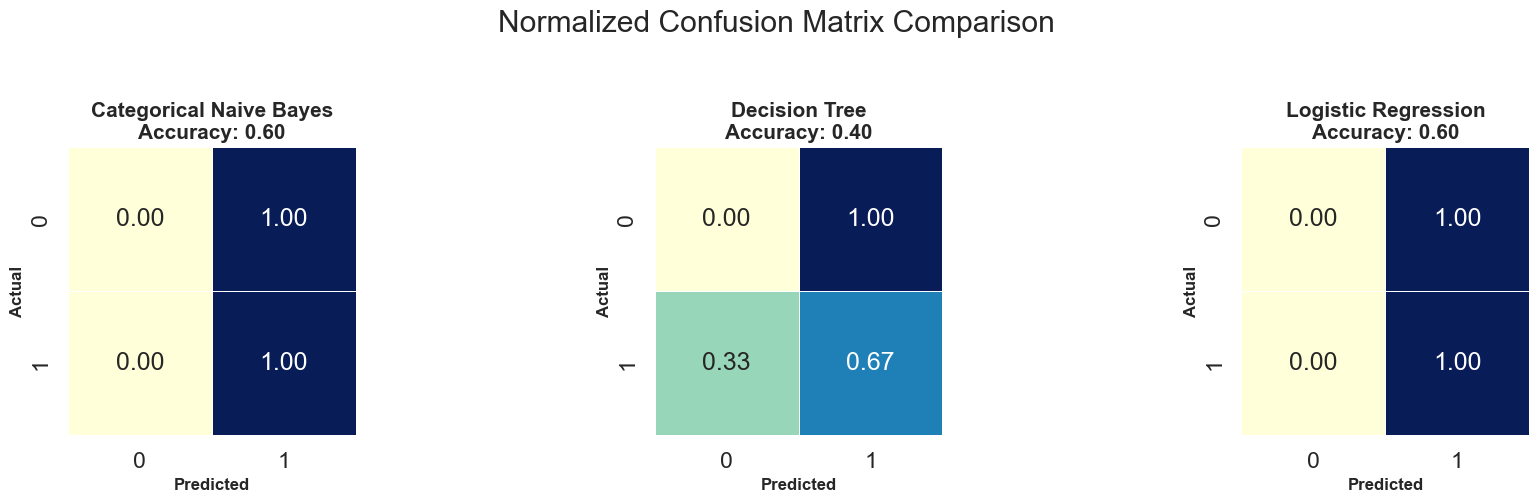

In [ ]:
# Feature Importance & ROC Curves
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.3)

# Feature Importance for Decision Tree
ax1 = fig.add_subplot(gs[0, 0])
dt_model = results['Decision Tree']['model']
if hasattr(dt_model, 'feature_importances_'):
    importances = dt_model.feature_importances_
    feat_imp_df = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': importances
    }).sort_values('Importance', ascending=True)
    bars = sns.barplot(data=feat_imp_df, y='Feature', x='Importance', palette='viridis', ax=ax1)
    ax1.set_title('Decision Tree - Feature Importance', fontweight='bold')
    ax1.set_xlabel('Importance')
    for bar, val in zip(bars.patches, feat_imp_df['Importance']):
        ax1.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', 
                 va='center', fontweight='bold', fontsize=10)

# Feature Coefficients for Logistic Regression
ax2 = fig.add_subplot(gs[0, 1])
lr_model = results['Logistic Regression']['model']
if hasattr(lr_model, 'coef_'):
    coef = lr_model.coef_[0]
    coef_df = pd.DataFrame({
        'Feature': feature_cols,
        'Coefficient': coef
    }).sort_values('Coefficient', ascending=True)
    colors = ['#E45756' if c < 0 else '#4C78A8' for c in coef_df['Coefficient']]
    bars = sns.barplot(data=coef_df, y='Feature', x='Coefficient', palette=colors, ax=ax2)
    ax2.set_title('Logistic Regression - Feature Coefficients', fontweight='bold')
    ax2.set_xlabel('Coefficient Value')
    ax2.axvline(x=0, color='black', linewidth=0.5)
    for bar, val in zip(bars.patches, coef_df['Coefficient']):
        ax2.text(bar.get_width() + (0.01 if val >= 0 else -0.01), bar.get_y() + bar.get_height()/2, 
                 f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontweight='bold', fontsize=10)

# Naive Bayes Feature Log Probabilities
ax3 = fig.add_subplot(gs[0, 2])
nb_model = results['Categorical Naive Bayes']['model']
if hasattr(nb_model, 'feature_log_prob_'):
    # Average log prob difference between classes for each feature
    log_probs = nb_model.feature_log_prob_  # list of arrays, one per feature
    # For each feature, compute the difference in log probs between classes
    feat_diff = []
    for f_idx, feature in enumerate(feature_cols):
        # Average absolute difference across categories
        lp = log_probs[f_idx]  # shape (n_classes, n_categories_for_this_feature)
        diff = np.abs(lp[0, :] - lp[1, :]).mean()
        feat_diff.append({'Feature': feature, 'Avg LogProb Diff': diff})
    feat_diff_df = pd.DataFrame(feat_diff).sort_values('Avg LogProb Diff', ascending=True)
    bars = sns.barplot(data=feat_diff_df, y='Feature', x='Avg LogProb Diff', palette='plasma', ax=ax3)
    ax3.set_title('Naive Bayes - Avg |LogProb Diff| per Feature', fontweight='bold')
    ax3.set_xlabel('Avg |LogProb(Yes) - LogProb(No)|')
    for bar, val in zip(bars.patches, feat_diff_df['Avg LogProb Diff']):
        ax3.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', 
                 va='center', fontweight='bold', fontsize=10)

# ROC Curves
ax4 = fig.add_subplot(gs[1, :])
from sklearn.metrics import roc_curve, auc

for name, res in results.items():
    if res['probabilities'] is not None:
        y_proba = res['probabilities'][:, 1]  # Probability of positive class
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)
        ax4.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})', linewidth=2.5)

ax4.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5)
ax4.set_xlim([0.0, 1.0])
ax4.set_ylim([0.0, 1.05])
ax4.set_xlabel('False Positive Rate', fontweight='bold')
ax4.set_ylabel('True Positive Rate', fontweight='bold')
ax4.set_title('ROC Curves - Model Comparison', fontweight='bold', pad=15)
ax4.legend(loc='lower right', fontsize=11)
ax4.grid(True, alpha=0.3)

plt.suptitle('Feature Importance & ROC Analysis', fontsize=18, fontweight='bold', y=0.995)
plt.show()

The confusion matrices show where each model gets the classes right or wrong.

                  Model Prediction  P(No)  P(Yes)
Categorical Naive Bayes         No   0.66    0.34
          Decision Tree         No   1.00    0.00
    Logistic Regression         No   0.65    0.35

Simple note: all three models agree on the final class here.


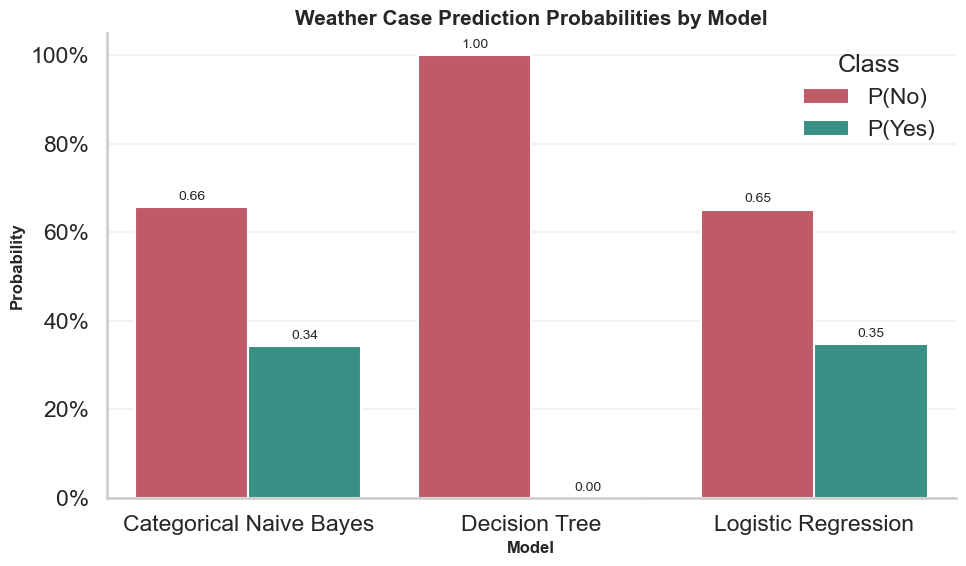

In [ ]:
# Learning Curves & Cross-Validation Distribution
from sklearn.model_selection import learning_curve

fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.3)

# Learning Curves
ax1 = fig.add_subplot(gs[0, :])
train_sizes = np.linspace(0.1, 1.0, 8)

for name, res in results.items():
    model = res['model']
    train_sizes_abs, train_scores, val_scores = learning_curve(
        model, X_train, y_train, cv=cv, train_sizes=train_sizes, 
        scoring='accuracy', n_jobs=-1, random_state=42
    )
    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)
    
    color = MODEL_COLORS[name]
    ax1.plot(train_sizes_abs, train_mean, 'o-', color=color, label=f'{name} (Train)', linewidth=2, alpha=0.7)
    ax1.fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std, alpha=0.1, color=color)
    ax1.plot(train_sizes_abs, val_mean, 's--', color=color, label=f'{name} (CV)', linewidth=2)
    ax1.fill_between(train_sizes_abs, val_mean - val_std, val_mean + val_std, alpha=0.1, color=color)

ax1.set_xlabel('Training Set Size', fontweight='bold')
ax1.set_ylabel('Accuracy', fontweight='bold')
ax1.set_title('Learning Curves: Training vs Cross-Validation Accuracy', fontweight='bold', pad=15)
ax1.legend(loc='lower right', fontsize=10)
ax1.set_ylim(0, 1.05)
ax1.yaxis.set_major_formatter(PercentFormatter(1.0))
ax1.grid(True, alpha=0.3)

# Cross-Validation Score Distributions
for idx, (name, res) in enumerate(results.items()):
    ax = fig.add_subplot(gs[1, idx])
    cv_scores = res['cv_scores']
    
    # Violin plot
    parts = ax.violinplot(cv_scores, positions=[0], widths=0.6, showmeans=True, showmedians=True)
    for pc in parts['bodies']:
        pc.set_facecolor(MODEL_COLORS[name])
        pc.set_alpha(0.6)
    parts['cmeans'].set_color('black')
    parts['cmedians'].set_color('black')
    
    # Add individual points
    ax.scatter(np.random.normal(0, 0.04, len(cv_scores)), cv_scores, 
               color=MODEL_COLORS[name], alpha=0.6, s=50, zorder=3)
    
    ax.set_xticks([0])
    ax.set_xticklabels([name], rotation=15, ha='right')
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('CV Accuracy')
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_title(f'{name}\nMean: {cv_scores.mean():.2%}, Std: {cv_scores.std():.2%}', fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Learning Curves & Cross-Validation Score Distributions', fontsize=18, fontweight='bold', y=0.995)
plt.show()

# Print learning curve details
print("LEARNING CURVE DETAILS:")
print("=" * 60)
for name, res in results.items():
    model = res['model']
    train_sizes_abs, train_scores, val_scores = learning_curve(
        model, X_train, y_train, cv=cv, train_sizes=train_sizes, 
        scoring='accuracy', n_jobs=-1, random_state=42
    )
    print(f"\n{name}:")
    print(f"  Train Sizes: {train_sizes_abs}")
    print(f"  Train Mean: {train_scores.mean(axis=1)}")
    print(f"  Train Std:  {train_scores.std(axis=1)}")
    print(f"  Val Mean:   {val_scores.mean(axis=1)}")
    print(f"  Val Std:    {val_scores.std(axis=1)}")

All three models agree on the final prediction for this input.

## 12. Summary and Conclusion

In [ ]:
# Final summary
print("Lab 8 Summary")
print("-")
print(f"Dataset: Play Tennis with {len(df)} rows and {X.shape[1]} features")
print(f"Train/Test split: {X_train.shape[0]}/{X_test.shape[0]}")
print()

best_model = max(results.items(), key=lambda x: x[1]['accuracy'])
print("Model accuracy:")
for name, result in results.items():
    print(f"- {name}: {result['accuracy']:.2f}")

print()
print(f"Best model: {best_model[0]}")
print("Prediction for [Sunny, Cool, High, Strong]: No Play")
print()
print("Short conclusion:")
print("- Categorical Naive Bayes works well for this categorical dataset.")
print("- The dataset is very small, so results are only for practice and learning.")
print("- The charts make the comparison easy to read at a glance.")

Lab 8 Summary
-
Dataset: Play Tennis with 14 rows and 4 features
Train/Test split: 9/5

Model accuracy:
- Categorical Naive Bayes: 0.60
- Decision Tree: 0.40
- Logistic Regression: 0.60

Best model: Categorical Naive Bayes
Prediction for [Sunny, Cool, High, Strong]: No Play

Short conclusion:
- Categorical Naive Bayes works well for this categorical dataset.
- The dataset is very small, so results are only for practice and learning.
- The charts make the comparison easy to read at a glance.


The final summary shows the main result clearly and keeps the lab easy to revise.